# Convolutions and Filtering
For two discrete-time signals  and , the convolution is defined as:
$$
y[n] = (x * h)[n] = \sum_{k=-\infty}^{\infty} x[k] h[n-k]
$$
where  is the input signal,  is the system's impulse response, and  is the output.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve, lfilter, freqz
import sounddevice as sd
from scipy.io.wavfile import write

## Convolution of x = [1,2,3,4] and h = [0.5, 0.5]

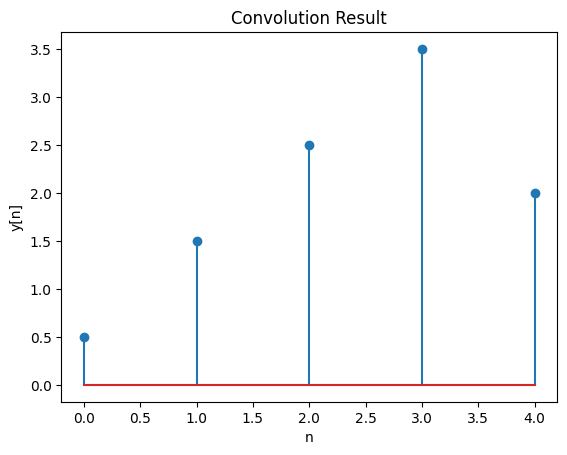

In [3]:
x = np.array([1, 2, 3, 4])
h = np.array([0.5, 0.5])
# Perform convolution:
y = convolve(x, h, mode='full')
plt.figure()
plt.stem(y)
plt.title('Convolution Result')
plt.xlabel('n')
plt.ylabel('y[n]')
plt.show()

## Linear Constant-Coefficient Difference Equations
A subcalss of LTI systems satisfy an Nth-order linear constant-coefficient difference equation:

$$
\sum_{k=0}^{N}a_{k}y[n-k] = \sum_{k=0}^{M}b_{k}x[n-k] \ \text{.}
$$

When working with systems described by an LCCDE, we use the scipy.signal lfilter command.

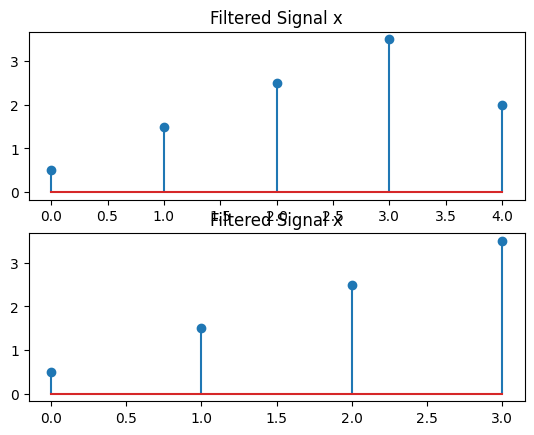

In [4]:
x = np.array([1, 2, 3, 4])
h = np.array([0.5, 0.5])

# Perform convolution:
y1 = convolve(x, h, mode='full')
plt.figure()
plt.subplot(2, 1, 1)
plt.stem(y1)
plt.title('Filtered Signal x')

# Perform filtering using lfilter:
y2 = lfilter(h,1,x)
plt.subplot(2, 1, 2)
plt.stem(y2)
plt.title('Filtered Signal x')
plt.show()

The lfilter command only provides an output when there is a current input sample.
You can flush the filter command by adding extra zeros at the end of the input.

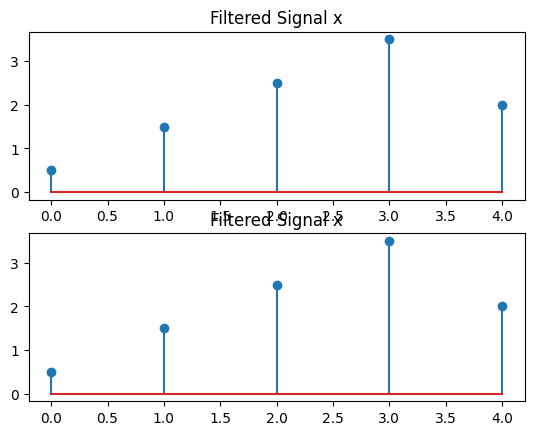

In [7]:
x = np.array([1, 2, 3, 4])
h = np.array([0.5, 0.5])

# Perform convolution:
y1 = convolve(x, h, mode='full')
plt.figure()
plt.subplot(2, 1, 1)
plt.stem(y1)
plt.title('Filtered Signal x')

# Perform filtering using lfilter:
x2 = np.append(x, 0)  # Adds a zero at the end
y2 = lfilter(h,1,x2)
plt.subplot(2, 1, 2)
plt.stem(y2)
plt.title('Filtered Signal x')
plt.show()

## Implementing the system y[n] = 0.5x[n] + 0.5y[n-1]

when $x[n] = [1,1,1,1,1]$ and $x[n] = [1,-1,1,-1,1]$. Note that this is an IIR filter. Based on the output shown for the two different inputs, decide what kind of filter (low-pass or high-pass) is described by the system.

### IFilter is just an LCCDE function:

$$\sum_{k=0}^{N} a_k y[n-k] = \sum_{k=0}^{M} b_k x[n-k]$$

### `b` and `a` arrays in `lfilter`

For the system **y[n] = 0.5x[n] + 0.5y[n-1]**, `lfilter` solves the LCCDE:

$$a_0 y[n] = b_0 x[n] - a_1 y[n-1]$$

- **`b = [0.5]`** — input coefficients: `b[0]=0.5` is the coefficient of x[n]
- **`a = [1, -0.5]`** — feedback coefficients: `a[0]=1` (y[n]), `a[1]=-0.5` encodes +0.5y[n-1]

The negative sign on `a[1]` is `lfilter`'s convention — it subtracts feedback terms, so a negative `a[k]` produces a positive feedback contribution.

The Ifilter function in the LCCDE format is always this way: $$a_0 y[n] = f ( x[n] , y[n] )$$
Same with MatLab's filter function


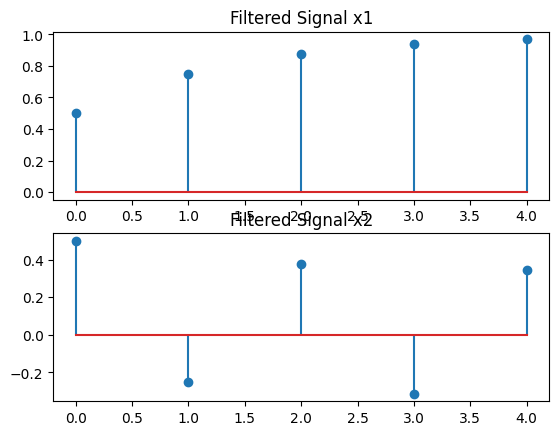

In [ ]:
x1 = np.array([1, 1, 1, 1, 1])
x2 = np.array([1, -1, 1, -1, 1])
b = [0.5]
a = [1,-0.5]

# Explain how the b array
y1 = lfilter(b, a, x1)
y2 = lfilter(b, a, x2)

plt.figure()
plt.subplot(2, 1, 1)
plt.stem(y1)
plt.title('Filtered Signal x1')

plt.subplot(2, 1, 2)
plt.stem(y2)
plt.title('Filtered Signal x2')
plt.show()

## Record the sentence: 'She has a watch thin as a dime'

Recording... Speak Now
Recording complete.
<class 'numpy.ndarray'>
float32


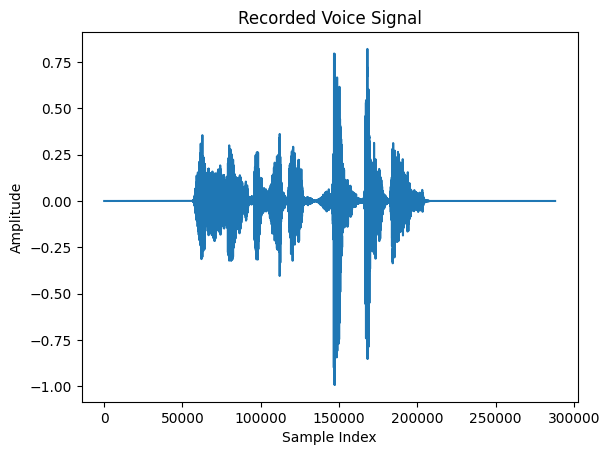

In [10]:
fs = 48000  # Sampling frequency
duration = 6.0  # Duration in seconds
print('Recording... Speak Now')
recording = sd.rec(int(duration * fs), samplerate=fs, channels=1, dtype='float32')
sd.wait()
print('Recording complete.')
print(type(recording))
print(recording.dtype)
# Convert to 16-bit PCM format
recording_int16 = np.int16(recording * 32767)
# Save as WAV file
write('sentence.wav', fs, recording_int16)
plt.figure()
plt.plot(recording)
plt.title('Recorded Voice Signal')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.show()

## Window Your Voice Signal

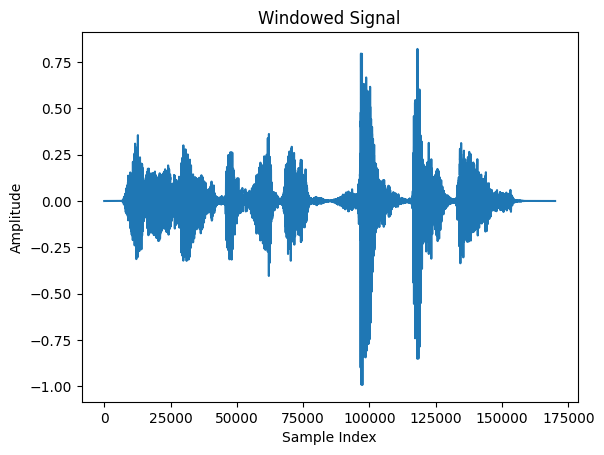

In [13]:
# By looking at the plot, I can tell that the signal starts at 50000 index and ends at 220000 index.
start_idx = 50000  # Adjust based on visualization
end_idx = 220000  # Adjust based on visualization
windowed_signal = recording[start_idx:end_idx]
plt.figure()
plt.plot(windowed_signal)
plt.title('Windowed Signal')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.show()

## 1. Truncated Ideal Low-Pass Filter
Create an ideal truncated low-pass filter based on the following formula:

$$
H(e^{j\omega}) =
\begin{cases} 
1\cdot e^{-j\alpha\omega}, & |\omega| < \omega_c \\
0, & \omega_c < |\omega| \leq \pi
\end{cases}
$$
Compute the Analytic Solution for the impulse response below:  
Show your work using LaTeX equations below.

$$
h(n) = \frac{1}{2\pi} \int_{-\omega_c}^{\omega_c} e^{-j\alpha\omega} e^{jn\omega} d\omega 
= ?
$$
Determine and plot the truncated impulse response 

$$
h[n] \ \text{for} \ 0 \le n < N-1
$$
using $N = 61$, $\alpha = 30$. Choose $\omega_c$ so that the cut-off frequency is 1500 Hz.

### FIR Low-Pass Filter Design

**Normalized cutoff frequency:**
$$\omega_c = \frac{2\pi \times 1500}{f_s}$$
`wc` converts the cutoff (1500 Hz) into radians/sample — the range [0, π] maps to [0, fs/2].

**Ideal low-pass filter (sinc) with Hanning window:**
$$h[n] = \frac{\omega_c}{\pi} \cdot \text{sinc}\!\left(\frac{\omega_c}{\pi}(n - \alpha)\right) \cdot w[n]$$

- $\frac{\omega_c}{\pi} \cdot \text{sinc}(\cdot)$ — the **ideal LPF impulse response** in discrete time; sinc in time = rectangular in frequency
- $(n - \alpha)$ — shifts the filter to be **causal** (centred at $\alpha = 30$, the middle of the 61-tap window)
- $w[n]$ (`np.hanning(61)`) — **Hanning window** to taper the sinc, reducing side-lobe ripple in the frequency response at the cost of a wider transition band


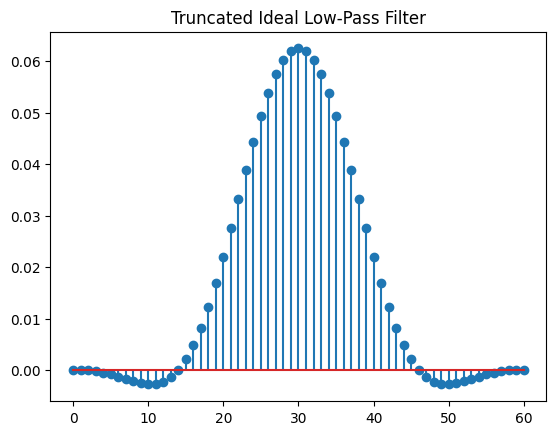

In [15]:
n = np.arange(61)
alpha = 30
fs = 48000
wc = 2 * np.pi * 1500 / fs  # Normalized cutoff frequency (1500 Hz)
lpFilt = (wc/np.pi) * np.sinc((wc/np.pi)*(n-alpha)) * np.hanning(61)   # Truncated ideal low-pass filter with Hanning window

plt.figure()
plt.stem(n, lpFilt)
plt.title('Truncated Ideal Low-Pass Filter')
plt.show()

### Frequency Response of the Filter

**`freqz(lpFilt, 1)`** computes the frequency response of the FIR filter:
- `w` — frequency axis in radians/sample, from 0 to π
- `h` — complex frequency response H(e^jω) at each frequency in `w`
- The `1` is the `a` array (no feedback → FIR)

**`h_dB = 20 * np.log10(np.abs(h))`** converts to decibels:
- `np.abs(h)` — magnitude |H(e^jω)|
- `20 * log10(·)` — standard dB conversion for **amplitude** (use 10× for power)

A flat 0 dB passband and steep drop toward −∞ dB in the stopband indicates a good low-pass filter.


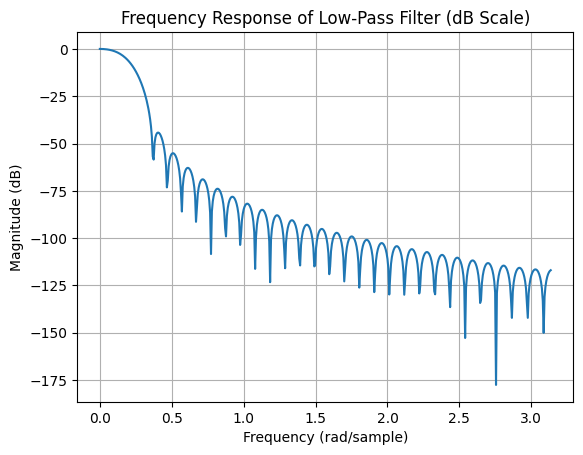

In [16]:
w, h = freqz(lpFilt, 1)
# Convert magnitude to decibels
h_dB = 20 * np.log10(np.abs(h))

# Plot frequency response in dB
plt.figure()
plt.plot(w, h_dB)
plt.title('Frequency Response of Low-Pass Filter (dB Scale)')
plt.xlabel('Frequency (rad/sample)')
plt.ylabel('Magnitude (dB)')
plt.grid()
plt.show()

### Apply Low-Pass Filter to the Voice Signal

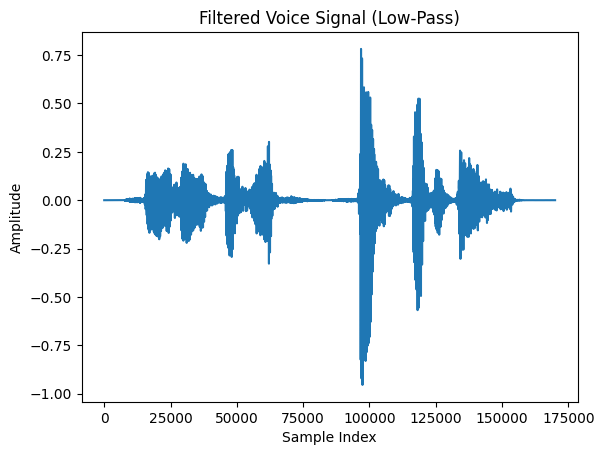

In [17]:
lpSig = lfilter(lpFilt, 1, windowed_signal.flatten())
plt.figure()
plt.plot(lpSig)
plt.title('Filtered Voice Signal (Low-Pass)')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.show()
# sd.play(lpSig, fs)  # Uncomment to listen to filtered signal

## 2. Truncated Ideal High-Pass Filter

Create an ideal truncated high-pass filter based on the following formula:

$$
H(e^{j\omega}) =
\begin{cases} 
1\cdot e^{-j\alpha\omega}, & \omega_c < |\omega| \leq \pi \\
0, & |\omega| \leq \omega_c
\end{cases}
$$
Compute the Analytic Solution for the impulse response below:
Show your work using latex equations below.
Put work here:

$$
h(n) = \frac{1}{2\,\pi}\int_{-\pi}^{-\omega_c}e^{j\,\omega(n-\alpha)}d\omega + \frac{1}{2\,\pi}\int_{\omega_c}^{\pi}e^{j\,\omega(n-\alpha)}d\omega
$$

$$
h(n) = \frac{1}{2\,\pi}\int_{-\pi}^{\pi}e^{j\,\omega(n-\alpha)}d\omega - \frac{1}{2\,\pi}\int_{-\omega_c}^{\omega_c}e^{j\,\omega(n-\alpha)}d\omega
$$

$$
h(n) = ?
$$

Determine and plot the truncated impulse response 

using $N = 61$, $\alpha = 30$. Choose $\omega_c$ so that the cut-off frequency is 2500 Hz.

### FIR High-Pass Filter Design

**`alpha = (Ntaps - 1) / 2`** — the **delay/centre index** of the filter.
With 61 taps, `alpha = 30`, so the impulse response is symmetric around sample 30, making the filter **linear phase**.

**`wc = 2π × 2500 / fs`** — normalized cutoff at 2500 Hz (same conversion as before).

**`hpFilt`** — starts from the same sinc formula as the low-pass case.
To convert a low-pass prototype into a **high-pass filter**, spectral inversion is applied:

$$h_{HP}[n] = \delta[n - \alpha] - h_{LP}[n]$$

This flips the frequency response: what was the passband becomes the stopband and vice versa. The cutoff here is higher (2500 Hz vs 1500 Hz) so the high-pass filter passes frequencies **above 2500 Hz**.

> Note: if the next line subtracts `hpFilt` from a delta at `alpha`, that is the spectral inversion step completing the high-pass design.


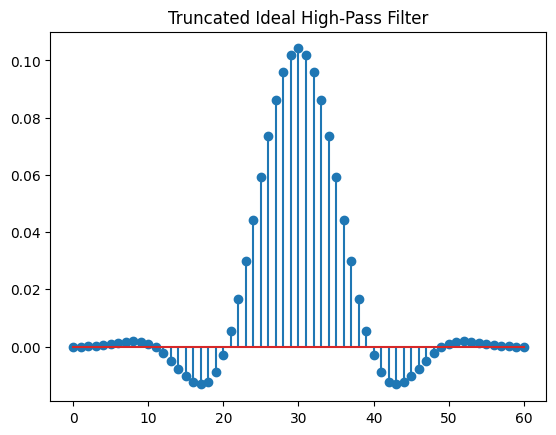

In [18]:
Ntaps = 61
n = np.arange(Ntaps)
alpha = (Ntaps - 1) / 2
wc = 2 * np.pi * 2500 / fs  # Normalized cutoff frequency (2500 Hz)
hpFilt = (wc/np.pi) * np.sinc((wc/np.pi)*(n-alpha)) * np.hanning(61)  # Truncated ideal high-pass filter with Hanning window

plt.figure()
plt.stem(n, hpFilt)
plt.title('Truncated Ideal High-Pass Filter')
plt.show()

### Apply High-Pass Filter to the Voice Signal

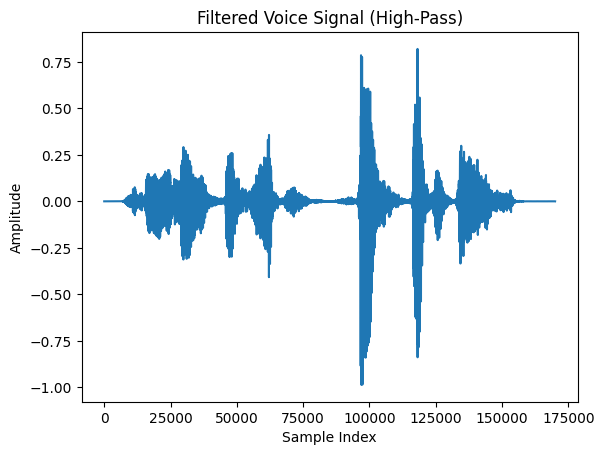

In [19]:
hpSig = lfilter(hpFilt, 1, windowed_signal.flatten())
plt.figure()
plt.plot(hpSig)
plt.title('Filtered Voice Signal (High-Pass)')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.show()
# sd.play(hpSig, fs)  # Uncomment to listen to filtered signal